# Parte 2 - Algoritmo para detecciones múltiples

Plantear y validar un algoritmo para múltiples detecciones en la imagen coca_multi.png con el mismo template del ítem 1.

Para este punto definimos la clase **MultipleLogoDetector**.

El algoritmo provisto por la clase detecta múltiples apariciones de un mismo logo en una imagen utilizando la técnica de **template matching** con detección multi-escala. Se basa en la comparación de bordes entre un template de referencia y distintas escalas de la imagen de entrada.

#### 1. Procesamiento del Template

1. **Lectura del template**
   Se carga una imagen en escala de grises desde una ruta especificada.

2. **Extracción de bordes**
   Se aplica el detector de bordes **Canny** al template para enfocarse en la estructura visual y reducir el impacto de los colores o texturas.

#### 2. Procesamiento de la Imagen de Entrada

1. **Conversión a escala de grises**
   Si la imagen original está en color, se convierte a escala de grises.

2. **Suavizado**
   Se aplica un suavizado Gaussiano para reducir el ruido que pueda interferir con la detección de bordes.

3. **Extracción de bordes**
   Se utiliza nuevamente el detector de bordes **Canny** con parámetros similares a los del template, para mantener la consistencia visual entre ambos.

#### 3. Generación de Escalas

1. **Cálculo de escalas**
   Se generan escalas de redimensionamiento adaptativas basadas en las proporciones entre el tamaño del template y la imagen de entrada.

2. **Distribución logarítmica**
   Las escalas se distribuyen logarítmicamente para explorar eficientemente distintos tamaños posibles del logo dentro de la imagen.


#### 4. Búsqueda del Template en Múltiples Escalas

1. **Redimensionamiento**
   Para cada escala, se redimensiona la imagen y se realiza la búsqueda del template.

2. **Template Matching**
   Se emplea la correlación normalizada para comparar el template de bordes con la imagen redimensionada.

3. **Filtrado por umbral de confianza**
   Solo se consideran las coincidencias que superan un umbral mínimo de confianza definido.

4. **Transformación de coordenadas**
   Las ubicaciones detectadas en la imagen redimensionada se transforman nuevamente al sistema de coordenadas de la imagen original.


#### 5. Filtrado de Detecciones Redundantes (NMS)

1. **Ordenamiento por confianza**
   Las detecciones se ordenan de mayor a menor según su nivel de coincidencia.

2. **Aplicación de Non-Maximum Suppression (NMS)**
   Se eliminan detecciones redundantes que se solapan en exceso con otras de mayor confianza, usando el criterio de **IoU (Intersection over Union)**.


#### 6. Visualización de Resultados

1. **Dibujo de bounding boxes**
   Se dibujan cajas verdes sobre las regiones donde se detectaron logos.

2. **Mostrado de la confianza (opcional)**
   Si está habilitado, se muestra sobre cada caja el porcentaje de coincidencia con el template.

#### Parámetros Personalizables

* **Rango de escalas** (`min_scale_factor`, `max_scale_factor`)
* **Cantidad de pasos de escala** (`scale_steps`)
* **Umbral de confianza mínima** (`confidence_threshold`)
* **Umbral de supresión IoU** (`nms_iou_threshold`)

In [1]:
import os
import cv2
import matplotlib.pyplot as plt
from mutliple_logo_detector import MultipleLogoDetector

In [2]:
template_path = "material/template/pattern.png"
image_path = "material/images/coca_multi.png"

if not os.path.exists(template_path):
    print(f"Error: No se encuentra el template en {template_path}")


if not os.path.exists(image_path):
    print(f"Error: No se encuentra la imagen en {image_path}")

Ponemos a prueba el algoritmo:

In [3]:
detector = MultipleLogoDetector(template_path)
print("✓ Detector inicializado exitosamente")

✓ Detector inicializado exitosamente


In [4]:
image = cv2.imread(image_path)
if image is None:
    print(f"Error: No se pudo cargar la imagen desde {image_path}")
print(f"✓ Imagen cargada: {image.shape}")

✓ Imagen cargada: (598, 799, 3)


Utilizamos un nivel de confianza que podría considerarse bajo, porque evidenciamos que los logos son encontrados con un nivel que no supera el puntaje de 17.1% para ningún caso.

In [17]:
# Detectar logos
print("Detectando logos...")
detections = detector.detect_logos(
    image, confidence_threshold=0.1
)

print(f"✓ Se encontraron {len(detections)} logos")

Detectando logos...
✓ Se encontraron 17 logos


In [18]:
for i, (confidence, x1, y1, x2, y2) in enumerate(detections, 1):
    print(
        f"  Logo {i}: Confianza {confidence:.1%}, "
        f"Posición ({x1}, {y1}) - ({x2}, {y2})"
    )

  Logo 1: Confianza 17.1%, Posición (270, 144) - (370, 188)
  Logo 2: Confianza 17.0%, Posición (437, 148) - (537, 191)
  Logo 3: Confianza 16.1%, Posición (23, 145) - (123, 188)
  Logo 4: Confianza 15.6%, Posición (103, 149) - (203, 192)
  Logo 5: Confianza 14.9%, Posición (557, 426) - (657, 470)
  Logo 6: Confianza 14.4%, Posición (399, 428) - (499, 471)
  Logo 7: Confianza 14.3%, Posición (228, 427) - (328, 471)
  Logo 8: Confianza 14.1%, Posición (142, 425) - (242, 469)
  Logo 9: Confianza 14.1%, Posición (66, 420) - (166, 464)
  Logo 10: Confianza 13.7%, Posición (481, 422) - (581, 465)
  Logo 11: Confianza 12.1%, Posición (300, 428) - (400, 472)
  Logo 12: Confianza 11.9%, Posición (196, 146) - (308, 195)
  Logo 13: Confianza 11.4%, Posición (623, 147) - (723, 190)
  Logo 14: Confianza 11.0%, Posición (651, 422) - (751, 466)
  Logo 15: Confianza 11.0%, Posición (694, 147) - (794, 191)
  Logo 16: Confianza 10.7%, Posición (534, 143) - (652, 195)
  Logo 17: Confianza 10.1%, Posició

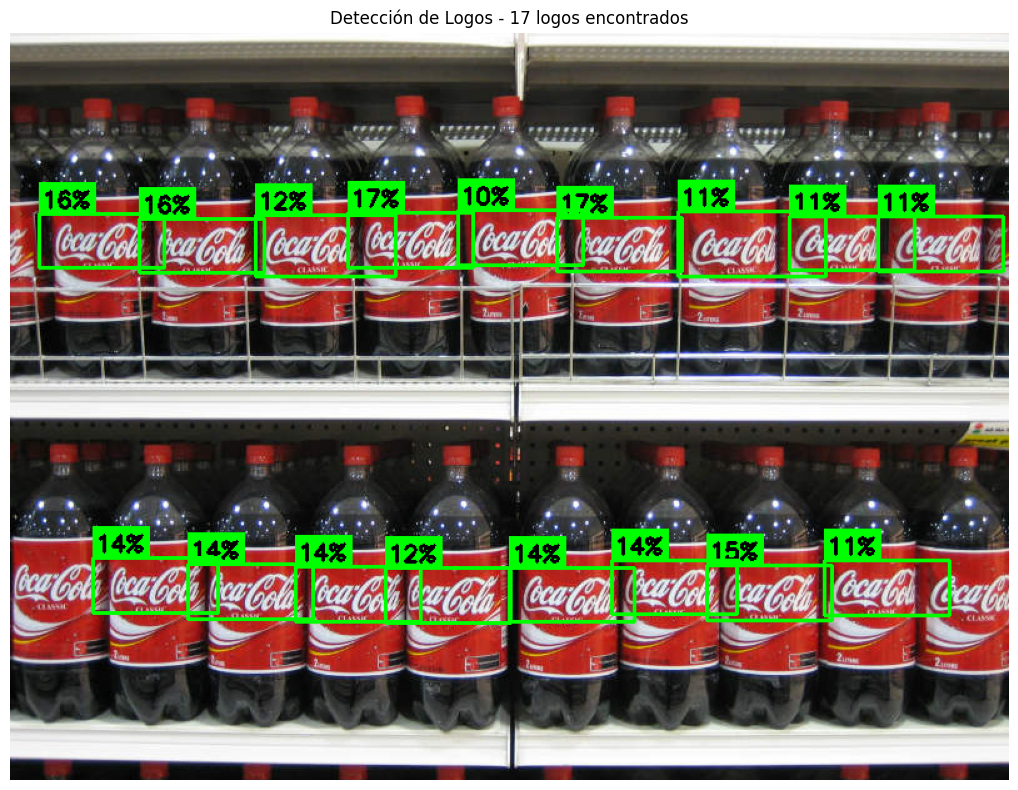

In [19]:
# Visualizar resultados
result_image = detector.visualize_detections(image, detections)

# Mostrar imagen
plt.figure(figsize=(12, 8))
plt.imshow(result_image)
plt.axis("off")
plt.title(f"Detección de Logos - {len(detections)} logos encontrados")
plt.tight_layout()
plt.show()